# Branches with lax.cond

Runnable locally on CPU or on a Cloud TPU VM.

- Locate the decision boundary
- Trace both branches and check their result types
- Choose cond or where by the shape of the question
- Inspect boundary behavior and derivatives

A Python branch can choose a path when it knows a value. Inside jit, that value may not be available yet. We’ll use lax.cond to make the choice at runtime, check what both branches must return, and compare a single decision with elementwise selection.

## The idea

A data-dependent branch needs a control-flow operation that can represent both alternatives in a transformed program. With a scalar predicate, `lax.cond` selects the result of one branch while requiring compatible result structures from both.

## Trace both possibilities, execute the selected rule

Consider an absolute-value rule: return the input when it is nonnegative and its negation otherwise. Both branches return the same shape and dtype, even though only one scalar case determines a particular result. The function is continuous at zero, but its mathematical derivative is not uniquely defined there.

The plot of magnitudes shows what the branch computes, not the tracing process. During tracing, Python code in both branch functions can be visited. Avoid using Python side effects as evidence that one numerical branch executed on the device.

After batching or other transformations, the implementation of control flow can change; for example, batching a conditional can turn it into selection. Keep claims about execution scope tied to the actual transformed program.

$$
\mathcal{T} = (\text{Leaves}(\mathcal{T}),\; \text{TreeDef}(\mathcal{T})), \qquad \operatorname{map}(g, \mathcal{T})_k = g(\mathcal{T}_k)
$$

### Pause and reason

Can one branch return a vector and the other a scalar if your current input only selects the vector?

<details><summary>Compare your reasoning</summary>

Not under the same conditional result contract. Both branches must produce compatible structures, shapes and dtypes so the transformed program has a well-defined result.

</details>

## Locate the decision boundary

The predicate $x\ge0$ is numerical data when $x$ is a traced argument. A Python if must choose a branch while tracing, before that runtime value is available. lax.cond represents the choice inside the staged computation instead.

Its arguments are a scalar Boolean predicate, two pure branch functions and an operand. Each branch receives that operand; each must return the same kind of result. Read the contract as an ordinary state transition with two possible implementations, not as a magic exception to tracing.

```text
predicate: x>=0
true:  operand x → x
false: operand x → −x
joined result: scalar float
```

## Trace both branches and check their result types

For a scalar predicate, cond selects one branch at runtime, but both branches are traced when building the computation. Therefore an invalid operation in a branch can fail during tracing even if a particular test input would not choose it.

Both result pytrees must agree and corresponding array leaves must have compatible shapes and dtypes. A scalar in one branch and a vector in the other cannot be joined by this contract. This is different from numerical correctness: matching output types can still hide a wrong branch formula.

## Choose cond or where by the shape of the question

cond makes one scalar decision for a computation. where chooses values elementwise from compatible arrays. A vector predicate naturally belongs to where or a deliberately batched conditional.

When cond is transformed with vmap over predicates, it can become selection. Do not use a branch as a promise that side effects or invalid arithmetic will never be evaluated under transformations. Keep functions pure and design numerical expressions that are valid in the relevant domain.

## Inspect boundary behavior and derivatives

Our magnitude function equals absolute value. Away from zero its derivative is +$1$ for positive inputs and $-1$ for negative inputs. At zero the mathematical function is not differentiable; a selected branch rule is a convention rather than proof of a derivative.

Test negative, positive and exact-boundary inputs because a `>` versus `>=` change can alter boundary behavior in other functions. Keep a separate argument about mathematical smoothness when differentiating conditional computations.

## Prepare the inputs

Create main.py in your lesson workspace. Add this first block; use the environment from setup.

In [1]:
# Step 1 — Prepare the inputs: These explicit inputs define the case that the later checks will...
# Import jax for this computation.
import jax
import jax.numpy as jnp

These explicit inputs define the case that the later checks will verify.

## Build the computation

Append this block below the inputs in the same file.

In [2]:
# Step 2 — Build the computation: Both branches return the same scalar type.
# Define and JIT-compile `magnitude(x)` so XLA traces and fuses the operations:
@jax.jit
# Function `magnitude(x)` implementing this stage's computation:
def magnitude(x):
    # Return `jax.lax.cond(x >= 0.0, lambda v: v, lambda v: -v, x)` to the caller.
    return jax.lax.cond(x >= 0., lambda v: v, lambda v: -v, x)

Both branches return the same scalar type. cond takes the runtime predicate and passes $x$ to the selected numerical branch.

## Run and check the result

Append the checks, save main.py, and run python main.py from this folder using your course environment.

In [3]:
# Step 3 — Run and check the result: Compare the output to the expected result below before making the...
# Print the observed values to compare against the expected result.
print(float(magnitude(-3.)))
# Assert that `jnp.allclose(magnitude(-3.), 3.)`.
assert jnp.allclose(magnitude(-3.), 3.)
# Assert that `jnp.allclose(magnitude(2.), 2.)`.
assert jnp.allclose(magnitude(2.), 2.)

3.0


Compare the output to the expected result below before making the exercise change.

## Run the example

In [4]:
# Step 1 — Prepare the inputs: These explicit inputs define the case that the later checks will...
# Import jax for this computation.
import jax
import jax.numpy as jnp
# Step 2 — Build the computation: Both branches return the same scalar type.
# Define and JIT-compile `magnitude(x)` so XLA traces and fuses the operations:
@jax.jit
# Function `magnitude(x)` implementing this stage's computation:
def magnitude(x):
    # Return `jax.lax.cond(x >= 0.0, lambda v: v, lambda v: -v, x)` to the caller.
    return jax.lax.cond(x >= 0., lambda v: v, lambda v: -v, x)
# Step 3 — Run and check the result: Compare the output to the expected result below before making the...
# Print the observed values to compare against the expected result.
print(float(magnitude(-3.)))
# Assert that `jnp.allclose(magnitude(-3.), 3.)`.
assert jnp.allclose(magnitude(-3.), 3.)
# Assert that `jnp.allclose(magnitude(2.), 2.)`.
assert jnp.allclose(magnitude(2.), 2.)

3.0


Expected: $3.0$

## Both branches form one magnitude function

Predict: What happens on each side of zero?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Both branches form one magnitude function
# Generate a uniform grid of points in `grid`.
grid = jnp.linspace(-3.0, 3.0, 25)
# Vectorize across the batch dimension without a Python loop (`visual_data`).
visual_data = {'kind': 'line', 'x': grid.tolist(), 'xlabel': 'input', 'ylabel': 'magnitude', 'series': [{'label': 'lax.cond output', 'y': jax.vmap(magnitude)(grid).tolist()}]}

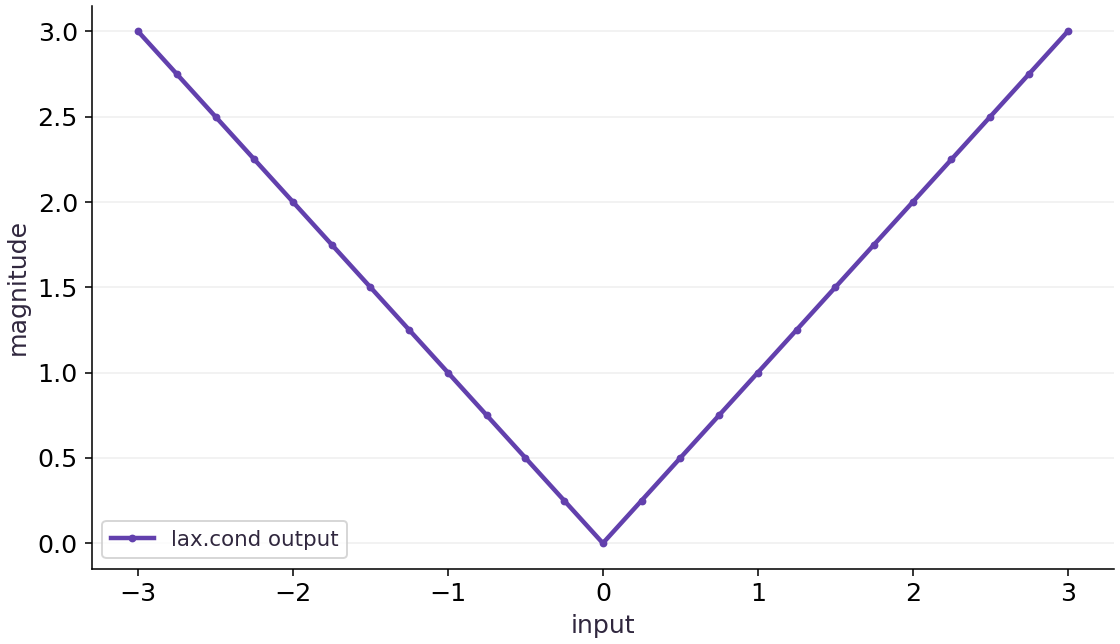

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis varies the input and the vertical axis gives the returned magnitude. The V-shaped line passes through $(-3,3)$, $(0,0)$, and $(3,3)$. Equal distances to the left and right of zero produce equal outputs.

The left arm comes from negating a negative input. The right arm comes from returning a nonnegative input unchanged. At zero the two values meet, so there is no jump in the output.

### Connect it to the computation

The branches together implement $|x|$. Moving right along the negative side decreases the result with slope $-1$; moving right along the positive side increases it with slope $1$. The sharp corner records that change of rule.

Continuity at the join does not imply differentiability: the classical derivative is undefined at zero because the two slopes disagree. A branch-selected autodiff value there must not be confused with a derivative of a smooth curve. The picture helps separate correct branch outputs from assumptions about gradients.

## Reproduce the Python truth-test failure

Predict: Why does eager evaluation choose a branch while jit cannot use a runtime value in Python if?

In [7]:
# Experiment — Reproduce the Python truth-test failure: The repair changes where the decision is represented.
def eager_branch(v):
    # Branch on condition `v >= 0.0`:
    if v>=0.:
        return v
    # Return `-v` to the caller.
    return -v
# Assert invariant `eager_branch(-3.)==3.` holds
assert eager_branch(-3.)==3.
# Run the boundary check and catch the expected exception:
try:
    jax.jit(eager_branch)(jnp.array(-3.))
except jax.errors.TracerBoolConversionError:
    print("Expected traced Python Boolean failure")
else:
    raise AssertionError("Expected branch error")
# Iterate over `v` to step through the computation:
for v in [-3.,0.,2.]:
    # Assert that `jnp.allclose(magnitude(v),abs(v))`.
    assert jnp.allclose(magnitude(v),abs(v))

Expected traced Python Boolean failure


Expected: The traced Python branch fails; cond gives the correct values for all three cases.

The repair changes where the decision is represented. It does not make $x$ static or remove the negative case.

## Check a batched numerical selection

Predict: Predict the outputs and derivatives away from the nonsmooth point.

In [8]:
# Experiment — Check a batched numerical selection: Correct values under batching do not imply a conditional branch...
# Construct `values` via `jnp.array([-3.,-1.,2.,4.])`
values=jnp.array([-3.,-1.,2.,4.])
# Assert that `jnp.allclose(jax.vmap(magnitude)(values),jnp.abs(values))`.
assert jnp.allclose(jax.vmap(magnitude)(values),jnp.abs(values))
# Assert that `jnp.allclose(jax.vmap(jax.grad(magnitude))(values),jnp.array([-1.,-1.,1.,1.]))`.
assert jnp.allclose(jax.vmap(jax.grad(magnitude))(values),jnp.array([-1.,-1.,1.,1.]))

Expected: Magnitudes $[3,1,2,4]$ and slopes $[-1,-1,1,1]$.

Correct values under batching do not imply a conditional branch remains lazy after every transformation.

## Your exercise

Write a compiled function that applies $2x$ when $x$ is positive and $x-2$ otherwise. Check positive, negative, and zero inputs.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.jit(fn) / @jax.jit` — Traces `fn` with abstract shapes and compiles a fused XLA executable cached by input shape and dtype.

**Step-by-step implementation plan:**
1. Define and JIT-compile `choose_update(x)` so XLA traces and fuses the operations:
2. Function `choose_update(x)` implementing this stage's computation:
3. Return `jax.lax.cond(x > 0.0, lambda v: v * 2.0, lambda v: v - 2.0, x)` to the caller.
4. Assert that `jnp.allclose(choose_update(3.), 6.)`.
5. Assert that `jnp.allclose(choose_update(-3.), -5.)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Write a compiled function that applies 2x when x is positive and x-2...
# Define and JIT-compile `choose_update(x)` so XLA traces and fuses the operations:
@jax.jit
# Function `choose_update(x)` implementing this stage's computation:
def choose_update(x):
    # Return `jax.lax.cond(x > 0.0, lambda v: v * 2.0, lambda v: v - 2.0, x)` to the caller.
    return ...  # TODO: return computed result
# Assert that `jnp.allclose(choose_update(3.), 6.)`.
assert jnp.allclose(choose_update(3.), 6.)  # TODO: complete assertion check
# Assert that `jnp.allclose(choose_update(-3.), -5.)`.
assert jnp.allclose(choose_update(-3.), -5.)  # TODO: complete assertion check
# Assert that `jnp.allclose(choose_update(0.), -2.)`.
assert jnp.allclose(choose_update(0.), -2.)  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Write a compiled function that applies 2x when x is positive and x-2...
# Define and JIT-compile `choose_update(x)` so XLA traces and fuses the operations:
# @jax.jit
# Function `choose_update(x)` implementing this stage's computation:
# def choose_update(x):
    # Return `jax.lax.cond(x > 0.0, lambda v: v * 2.0, lambda v: v - 2.0, x)` to the caller.
#     return ...  # TODO: return computed result
# Assert that `jnp.allclose(choose_update(3.), 6.)`.
# assert jnp.allclose(choose_update(3.), 6.)  # TODO: complete assertion check
# Assert that `jnp.allclose(choose_update(-3.), -5.)`.
# assert jnp.allclose(choose_update(-3.), -5.)  # TODO: complete assertion check
# Assert that `jnp.allclose(choose_update(0.), -2.)`.
# assert jnp.allclose(choose_update(0.), -2.)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Write a compiled function that applies 2x when x is positive and x-2...
# Define and JIT-compile `choose_update(x)` so XLA traces and fuses the operations:
@jax.jit
# Function `choose_update(x)` implementing this stage's computation:
def choose_update(x):
    # Return `jax.lax.cond(x > 0.0, lambda v: v * 2.0, lambda v: v - 2.0, x)` to the caller.
    return jax.lax.cond(x > 0., lambda v: v * 2., lambda v: v - 2., x)
# Assert that `jnp.allclose(choose_update(3.), 6.)`.
assert jnp.allclose(choose_update(3.), 6.)
# Assert that `jnp.allclose(choose_update(-3.), -5.)`.
assert jnp.allclose(choose_update(-3.), -5.)
# Assert that `jnp.allclose(choose_update(0.), -2.)`.
assert jnp.allclose(choose_update(0.), -2.)

## Match a changed piecewise rule · Practice

Implement $x^2$ for $x>1$ and $2x$ otherwise. Derive outputs at $-1$,$1$,$2$ and derivatives away from $1$.

Hint: At $x=1$ the false branch is selected.

### How to write: Match a changed piecewise rule — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.
- `jax.vmap(fn, in_axes=..., out_axes=...)` — Vectorizes a single-example function across a batch axis without writing a Python loop.

**Step-by-step implementation plan:**
1. Return `jax.lax.cond(v > 1.0, lambda z: z * z, lambda z: 2 * z, v)` to the caller.
2. Assert that `jnp.allclose(jax.vmap(piecewise)(jnp.array([-1.,1.,2.])),jnp.array([-2.,2.,4.]))`.
3. Assert that `jnp.allclose(jax.grad(piecewise)(-1.),2.)`.
4. Assert that `jnp.allclose(jax.grad(piecewise)(2.),4.)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Match a changed piecewise rule (Practice): The values check the exact boundary and both formulas; the...
def piecewise(v):
    # Return `jax.lax.cond(v > 1.0, lambda z: z * z, lambda z: 2 * z, v)` to the caller.
    return ...  # TODO: return computed result
# Assert that `jnp.allclose(jax.vmap(piecewise)(jnp.array([-1.,1.,2.])),jnp.array([-2.,2.,4.]))`.
assert jnp.allclose(jax.vmap(piecewise)(jnp.array([-1.,1.,2.])),jnp.array([-2.,2.,4.]))  # TODO: complete assertion check
# Assert that `jnp.allclose(jax.grad(piecewise)(-1.),2.)`.
assert jnp.allclose(jax.grad(piecewise)(-1.),2.)  # TODO: complete assertion check
# Assert that `jnp.allclose(jax.grad(piecewise)(2.),4.)`.
assert jnp.allclose(jax.grad(piecewise)(2.),4.)  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Match a changed piecewise rule (Practice): The values check the exact boundary and both formulas; the...
# def piecewise(v):
    # Return `jax.lax.cond(v > 1.0, lambda z: z * z, lambda z: 2 * z, v)` to the caller.
#     return ...  # TODO: return computed result
# Assert that `jnp.allclose(jax.vmap(piecewise)(jnp.array([-1.,1.,2.])),jnp.array([-2.,2.,4.]))`.
# assert jnp.allclose(jax.vmap(piecewise)(jnp.array([-1.,1.,2.])),jnp.array([-2.,2.,4.]))  # TODO: complete assertion check
# Assert that `jnp.allclose(jax.grad(piecewise)(-1.),2.)`.
# assert jnp.allclose(jax.grad(piecewise)(-1.),2.)  # TODO: complete assertion check
# Assert that `jnp.allclose(jax.grad(piecewise)(2.),4.)`.
# assert jnp.allclose(jax.grad(piecewise)(2.),4.)  # TODO: complete assertion check

## Reference reasoning

The values check the exact boundary and both formulas; the derivatives are checked only at smooth points.

In [12]:
# Match a changed piecewise rule (Practice): The values check the exact boundary and both formulas; the...
def piecewise(v):
    # Return `jax.lax.cond(v > 1.0, lambda z: z * z, lambda z: 2 * z, v)` to the caller.
    return jax.lax.cond(v>1.,lambda z:z*z,lambda z:2*z,v)
# Assert that `jnp.allclose(jax.vmap(piecewise)(jnp.array([-1.,1.,2.])),jnp.array([-2.,2.,4.]))`.
assert jnp.allclose(jax.vmap(piecewise)(jnp.array([-1.,1.,2.])),jnp.array([-2.,2.,4.]))
# Assert that `jnp.allclose(jax.grad(piecewise)(-1.),2.)`.
assert jnp.allclose(jax.grad(piecewise)(-1.),2.)
# Assert that `jnp.allclose(jax.grad(piecewise)(2.),4.)`.
assert jnp.allclose(jax.grad(piecewise)(2.),4.)

## Repair incompatible branch shapes · Challenge

Return a scalar in one branch and a length-two vector in the other, reproduce the error, then define a consistent two-value result.

Hint: Decide what each output component means before padding.

### How to write: Repair incompatible branch shapes — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Run the boundary check and catch the expected exception:
2. Function `pair(v)` implementing this stage's computation:
3. Return `jax.lax.cond(v >= 0.0, lambda x: jnp.stack([x, x * x]), lambda x: jnp.stack([-x, x * x]), v)` to the caller.
4. Assert that `jnp.allclose(pair(jnp.array(-2.)),jnp.array([2.,4.]))`.

**Starter code scaffold (fill in the TODOs):**

```python
# Repair incompatible branch shapes (Challenge): A branch mismatch is a result-contract error even when the...
# Run the boundary check and catch the expected exception:
try:
    jax.lax.cond(True,lambda x:x,lambda x:jnp.stack([x,x]),jnp.array(2.))
except TypeError:
    print("Expected branch shape mismatch")
else:
    raise AssertionError("Expected result type error")
# Function `pair(v)` implementing this stage's computation:
def pair(v):
    # Return `jax.lax.cond(v >= 0.0, lambda x: jnp.stack([x, x * x]), lambda x: jnp.stack([-x, x * x]), v)` to the caller.
    return ...  # TODO: return computed result
# Assert that `jnp.allclose(pair(jnp.array(-2.)),jnp.array([2.,4.]))`.
assert jnp.allclose(pair(jnp.array(-2.)),jnp.array([2.,4.]))  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Repair incompatible branch shapes (Challenge): A branch mismatch is a result-contract error even when the...
# Run the boundary check and catch the expected exception:
# try:
#     jax.lax.cond(True,lambda x:x,lambda x:jnp.stack([x,x]),jnp.array(2.))
# except TypeError:
#     print("Expected branch shape mismatch")
# else:
#     raise AssertionError("Expected result type error")
# Function `pair(v)` implementing this stage's computation:
# def pair(v):
    # Return `jax.lax.cond(v >= 0.0, lambda x: jnp.stack([x, x * x]), lambda x: jnp.stack([-x, x * x]), v)` to the caller.
#     return ...  # TODO: return computed result
# Assert that `jnp.allclose(pair(jnp.array(-2.)),jnp.array([2.,4.]))`.
# assert jnp.allclose(pair(jnp.array(-2.)),jnp.array([2.,4.]))  # TODO: complete assertion check

## Reference reasoning

A branch mismatch is a result-contract error even when the current predicate is known. Here the repaired output explicitly means [magnitude,square].

In [14]:
# Repair incompatible branch shapes (Challenge): A branch mismatch is a result-contract error even when the...
# Run the boundary check and catch the expected exception:
try:
    jax.lax.cond(True,lambda x:x,lambda x:jnp.stack([x,x]),jnp.array(2.))
except TypeError:
    print("Expected branch shape mismatch")
else:
    raise AssertionError("Expected result type error")
# Function `pair(v)` implementing this stage's computation:
def pair(v):
    # Return `jax.lax.cond(v >= 0.0, lambda x: jnp.stack([x, x * x]), lambda x: jnp.stack([-x, x * x]), v)` to the caller.
    return jax.lax.cond(v>=0.,lambda x:jnp.stack([x,x*x]),lambda x:jnp.stack([-x,x*x]),v)
# Assert that `jnp.allclose(pair(jnp.array(-2.)),jnp.array([2.,4.]))`.
assert jnp.allclose(pair(jnp.array(-2.)),jnp.array([2.,4.]))

Expected branch shape mismatch


## Checkpoint

Can one cond branch return a scalar and the other a length-three array?

1. Yes, any shapes are allowed
2. No, branch result types and shapes must be compatible
3. Only if the predicate is negative

## Diagnose

A branch mismatch is a result-contract error even when the current predicate is known. Here the repaired output explicitly means [magnitude,square].

## Evidence

Keep the branch-contract diagram, eager/jit failure and repair, boundary cases, batched values and off-boundary derivatives, and the shape-mismatch diagnosis.

## Carry forward

- The repair changes where the decision is represented. It does not make $x$ static or remove the negative case.
- Correct values under batching do not imply a conditional branch remains lazy after every transformation.

## Primary references

- [JAX cond](https://docs.jax.dev/en/latest/_autosummary/jax.lax.cond.html)
- [JAX control flow](https://docs.jax.dev/en/latest/control-flow.html)